## Potencial de oleaje

Por: Montserrat González


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)


Se carga el archivo .csv descargado de la boya oceánica (NOAA), el cual contiene información horaria del oleaje.

También se limpian los nombres de columnas para evitar errores por espacios ocultos.


In [ ]:
# Cargar archivo
df = pd.read_csv("data/Oleaje_Datos.csv")

# Limpiar nombres de columnas (por si vienen con espacios)
df.columns = df.columns.str.strip()

# Ver columnas
print(df.columns)


Index(['AÑO', 'MES', 'DIA', 'HR', 'MN', 'Fecha / Hora', '0.02', '0.0325',
       '0.0375', '0.0425', '0.0475', '0.0525', '0.0575', '0.0625', '0.0675',
       '0.0725', '0.0775', '0.0825', '0.0875', '0.0925', '0.1', '0.11', '0.12',
       '0.13', '0.14', '0.15', '0.16', '0.17', '0.18', '0.19', '0.2', '0.21',
       '0.22', '0.23', '0.24', '0.25', '0.26', '0.27', '0.28', '0.29', '0.3',
       '0.31', '0.32', '0.33', '0.34', '0.35', '0.365', '0.385', '0.405',
       '0.425', '0.445', '0.465', '0.485', 'Hs (m)', 'Te (s)', 'Fp (Hz)',
       'Pw (kW/m)', 'Pw prom anual (kW/m)', 'Unnamed: 58', ''],
      dtype='str')


Los datos contienen las columnas:

- Año (AÑO)
- Mes (MES)
- Día (DIA)
- Hora (HR)

Se realiza:

1. Eliminación de espacios
2. Conversión a tipo numérico
3. Eliminación de valores inválidos

Esto es necesario para construir correctamente la serie temporal.


In [ ]:
# Columnas de tiempo
cols_time = ["AÑO", "MES", "DIA", "HR"]

# Limpiar strings y espacios
for col in cols_time:
    df[col] = df[col].astype(str).str.strip()

# Convertir a numérico (manejo de errores)
for col in cols_time:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Eliminar filas inválidas
df = df.dropna(subset=cols_time)

# Convertir a enteros
for col in cols_time:
    df[col] = df[col].astype(int)


Se construye una variable tipo datetime que representa el tiempo exacto de cada medición.

Esto es fundamental para:

- análisis temporal
- agrupaciones por mes
- cálculos anuales


In [ ]:
df["datetime"] = pd.to_datetime(
    df["AÑO"].astype(str)
    + "-"
    + df["MES"].astype(str)
    + "-"
    + df["DIA"].astype(str)
    + " "
    + df["HR"].astype(str)
    + ":00"
)

# Ordenar
df = df.sort_values("datetime")

df.head()


,AÑO,MES,DIA,HR,MN,Fecha / Hora,0.02,0.0325,0.0375,0.0425,0.0475,0.0525,0.0575,0.0625,0.0675,0.0725,0.0775,0.0825,0.0875,0.0925,0.1,0.11,0.12,0.13,0.14,0.15,0.16,0.17,0.18,0.19,0.2,0.21,0.22,0.23,0.24,0.25,0.26,0.27,0.28,0.29,0.3,0.31,0.32,0.33,0.34,0.35,0.365,0.385,0.405,0.425,0.445,0.465,0.485,Hs (m),Te (s),Fp (Hz),Pw (kW/m),Pw prom anual (kW/m),Unnamed: 58,,datetime
1,2018,1,1,0,40.0,01/01/2018 00:40,0.0,0.0,0.0,0.0,0.0,0.08,0.27,3.57,6.84,6.21,5.41,3.43,1.68,1.21,0.89,0.78,0.71,0.65,0.45,0.52,0.57,0.55,0.75,0.61,0.27,0.29,0.13,0.12,0.09,0.07,0.08,0.07,0.08,0.11,0.04,0.05,0.05,0.05,0.07,0.04,0.01,0.01,0.01,0.01,0.01,0.01,0.01,1.902314,11.153682,0.0675,19.802264,29.845227,NaN,NaN,2018-01-01 00:00:00
2,2018,1,1,1,40.0,01/01/2018 01:40,0.0,0.0,0.0,0.0,0.0,0.00,0.25,6.01,9.79,10.37,7.72,3.29,3.39,1.81,0.70,0.45,0.99,0.82,0.58,0.75,0.35,0.54,0.59,0.24,0.21,0.19,0.17,0.24,0.14,0.09,0.09,0.06,0.06,0.06,0.07,0.05,0.05,0.04,0.03,0.03,0.02,0.02,0.01,0.02,0.02,0.01,0.01,2.163562,11.844518,0.0725,27.201199,NaN,NaN,NaN,2018-01-01 01:00:00
3,2018,1,1,2,40.0,01/01/2018 02:40,0.0,0.0,0.0,0.0,0.0,0.09,0.35,2.82,4.06,7.33,7.44,2.71,2.09,1.42,0.46,0.72,0.95,0.48,0.66,0.48,1.04,0.46,0.20,0.24,0.42,0.20,0.26,0.17,0.12,0.10,0.12,0.06,0.07,0.05,0.03,0.05,0.03,0.03,0.03,0.03,0.02,0.02,0.03,0.01,0.01,0.01,0.01,1.873926,11.064877,0.0775,19.062666,NaN,NaN,NaN,2018-01-01 02:00:00
4,2018,1,1,3,40.0,01/01/2018 03:40,0.0,0.0,0.0,0.0,0.0,0.03,0.49,2.96,9.90,11.43,5.16,2.76,2.79,1.72,1.15,0.90,0.99,0.76,0.56,0.40,0.59,0.80,0.42,0.36,0.22,0.19,0.11,0.17,0.09,0.12,0.10,0.08,0.03,0.10,0.04,0.07,0.05,0.05,0.02,0.04,0.05,0.02,0.03,0.02,0.01,0.01,0.00,2.092988,11.555399,0.0725,24.834222,NaN,NaN,NaN,2018-01-01 03:00:00
5,2018,1,1,4,40.0,01/01/2018 04:40,0.0,0.0,0.0,0.0,0.0,0.08,0.34,4.17,11.05,9.81,3.62,2.11,1.52,0.79,0.83,0.44,0.54,0.80,0.49,1.12,0.74,0.50,0.49,0.42,0.27,0.24,0.18,0.07,0.12,0.14,0.08,0.06,0.06,0.06,0.07,0.04,0.04,0.03,0.03,0.04,0.02,0.02,0.01,0.01,0.01,0.02,0.01,1.993389,11.637500,0.0675,22.686938,NaN,NaN,NaN,2018-01-01 04:00:00


Se seleccionan únicamente las variables necesarias para el análisis:

- Hs: altura significativa del oleaje
- Te: periodo energético
- Fp: frecuencia pico
- Pw: potencia del oleaje

Estas variables permiten caracterizar el comportamiento energético del oleaje.


In [ ]:
df = df[["datetime", "Hs (m)", "Te (s)", "Fp (Hz)", "Pw (kW/m)"]]


### Serie temporal de potencia del oleaje

Se grafica la potencia del oleaje (Pw) en función del tiempo.

Esto permite observar:

- variabilidad del recurso
- eventos de alta energía
- comportamiento anual


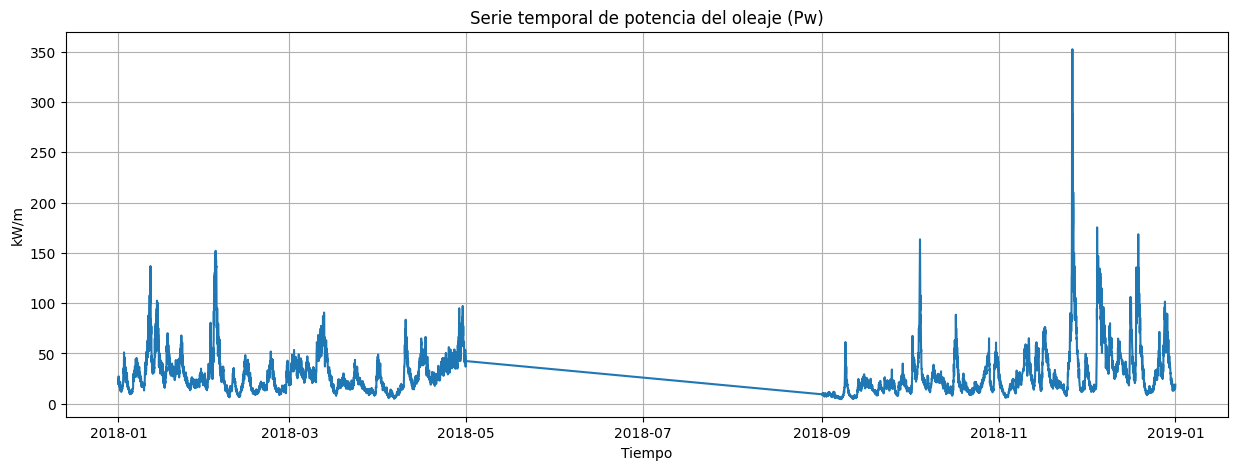

In [ ]:
plt.figure(figsize=(15, 5))
plt.plot(df["datetime"], df["Pw (kW/m)"])
plt.title("Serie temporal de potencia del oleaje (Pw)")
plt.xlabel("Tiempo")
plt.ylabel("kW/m")
plt.grid()
plt.show()


### Cálculo del promedio mensual

Se calcula el promedio de potencia del oleaje por mes.

Esto permite identificar:

- estacionalidad
- meses con mayor potencial energético


In [ ]:
df["mes"] = df["datetime"].dt.month

promedio_mensual = df.groupby("mes")["Pw (kW/m)"].mean()
promedio_mensual.index = ["Ene", "Feb", "Mar", "Abr", "Sep", "Oct", "Nov", "Dic"]

print(promedio_mensual)


Ene    32.260871
Feb    26.556136
Mar    28.299670
Abr    31.129128
Sep    14.441731
Oct    25.899180
Nov    34.522102
Dic    43.925289
Name: Pw (kW/m), dtype: float64


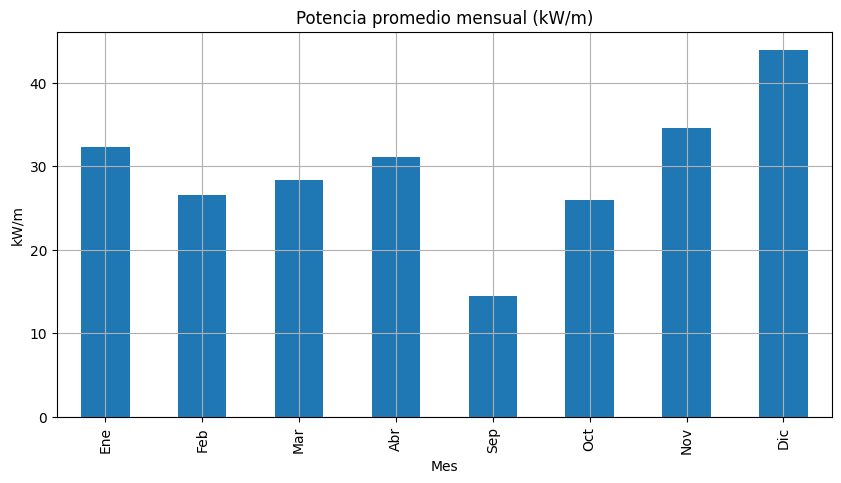

In [ ]:
promedio_mensual.plot(kind="bar", figsize=(10, 5))
plt.title("Potencia promedio mensual (kW/m)")
plt.xlabel("Mes")
plt.ylabel("kW/m")
plt.grid()
plt.show()


### Potencia promedio anual

Se obtiene el valor promedio de potencia del oleaje en todo el año.

Este valor representa la densidad energética media del sitio.


In [ ]:
promedio_anual = df["Pw (kW/m)"].mean()

print(f"Potencia promedio anual: {promedio_anual:.2f} kW/m")


Potencia promedio anual: 29.84 kW/m


### Cálculo de energía anual

La energía total se calcula a partir de:

- Potencia promedio (kW/m)
- Tiempo total del año (8760 horas)

Resultado:

- Energía en GWh por metro de frente de ola


In [ ]:
horas_anio = 8760

energia_anual_kWh = promedio_anual * horas_anio
energia_anual_GWh = energia_anual_kWh / 1e6

print(f"Energía anual: {energia_anual_GWh:.4f} GWh/m-año")


Energía anual: 0.2614 GWh/m-año


### Relación entre variables (Te, Hs, Pw)

Se analiza la relación entre:

- Periodo energético (Te)
- Altura de ola (Hs)
- Potencia (Pw)

Esto permite entender cómo influyen las características del oleaje en la energía disponible.


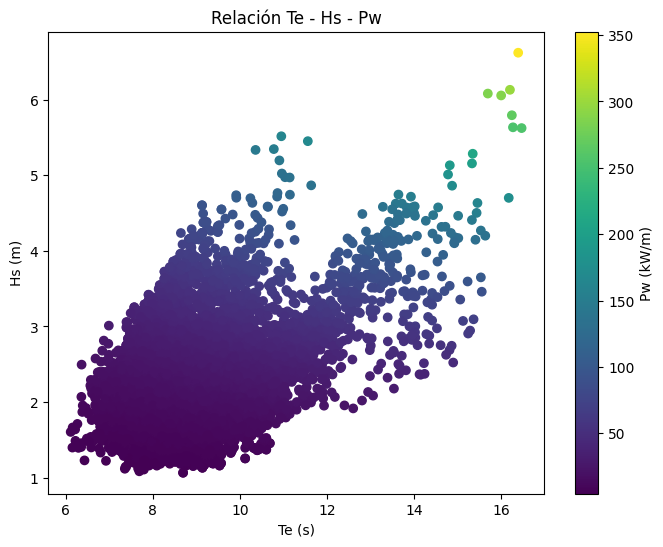

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(df["Te (s)"], df["Hs (m)"], c=df["Pw (kW/m)"])
plt.colorbar(label="Pw (kW/m)")
plt.xlabel("Te (s)")
plt.ylabel("Hs (m)")
plt.title("Relación Te - Hs - Pw")
plt.show()


### Relación con frecuencia

Se analiza la relación entre:

- Frecuencia (f)
- Altura (Hs)
- Energía (Pw)


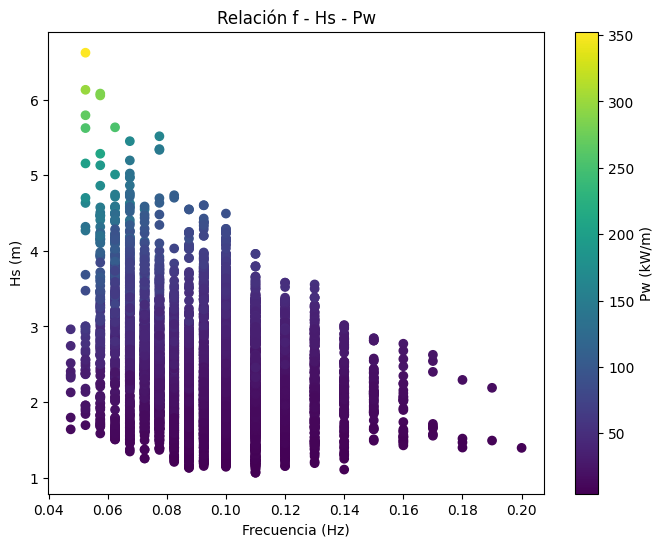

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(df["Fp (Hz)"], df["Hs (m)"], c=df["Pw (kW/m)"])
plt.colorbar(label="Pw (kW/m)")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Hs (m)")
plt.title("Relación f - Hs - Pw")
plt.show()


### Matriz de dispersión Hs–Te

La matriz de dispersión representa:
• Frecuencia de ocurrencia de combinaciones Hs–Te
• Base para el cálculo energético mediante histogramas

Se discretizan los datos en intervalos.


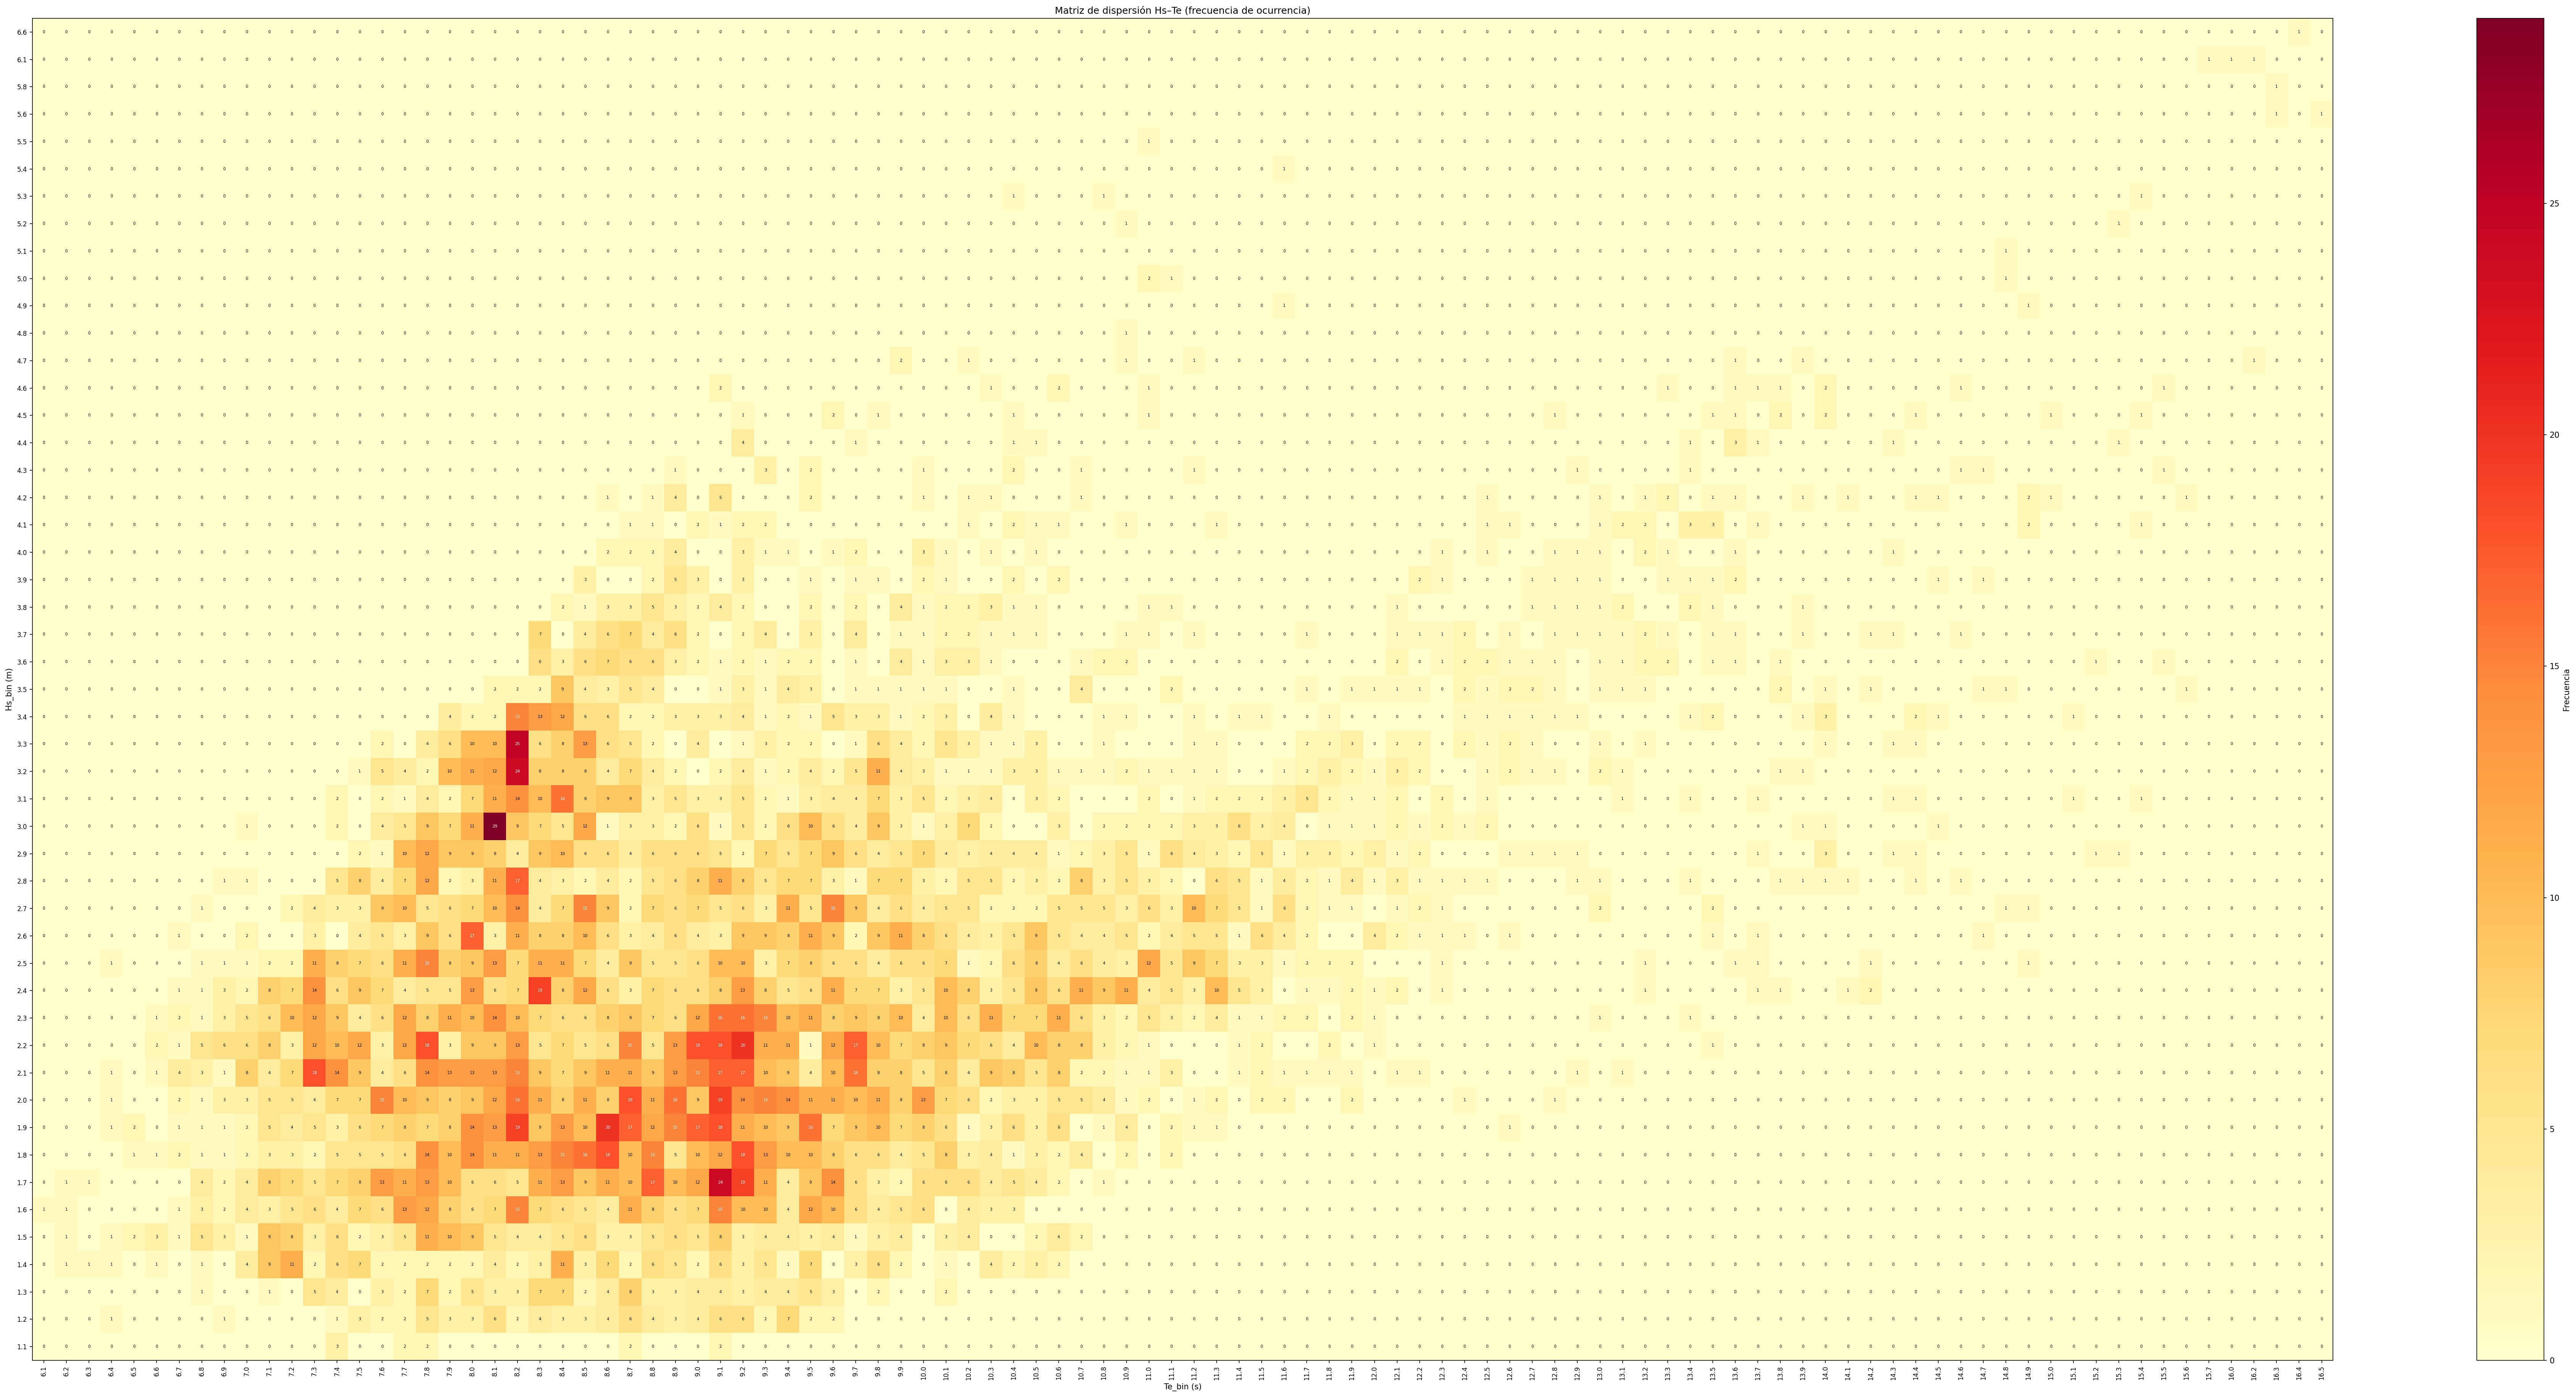

In [47]:
# Crear bins (redondeo)
df["Hs_bin"] = df["Hs (m)"].round(1)
df["Te_bin"] = df["Te (s)"].round(1)

# Matriz de ocurrencia (frecuencias)
matriz = pd.pivot_table(
    df,
    values="Pw (kW/m)",
    index="Hs_bin",
    columns="Te_bin",
    aggfunc="count",
    fill_value=0,
)

# Tamaño dinámico de figura según número de filas/columnas
n_rows, n_cols = matriz.shape
cell_size = 0.5  # tamaño por celda (ajustable)
fig_w = max(14, n_cols * cell_size)
fig_h = max(10, n_rows * cell_size)

plt.figure(figsize=(fig_w, fig_h), dpi=150)
im = plt.imshow(matriz.values, cmap="YlOrRd", aspect="auto", origin="lower")
plt.colorbar(im, label="Frecuencia")

# Etiquetas de ejes con bins reales
plt.xticks(ticks=np.arange(n_cols), labels=matriz.columns, rotation=90, fontsize=8)
plt.yticks(ticks=np.arange(n_rows), labels=matriz.index, fontsize=8)

# Tamaño de fuente dinámico para anotaciones
font_size = max(5, min(9, int(180 / max(n_rows, n_cols))))

# Anotar valores en cada celda
max_val = matriz.values.max()
for i in range(n_rows):
    for j in range(n_cols):
        v = matriz.values[i, j]
        color = "white" if v > max_val * 0.5 else "black"
        plt.text(
            j, i, f"{v}", ha="center", va="center", color=color, fontsize=font_size
        )

plt.title("Matriz de dispersión Hs–Te (frecuencia de ocurrencia)", fontsize=12)
plt.xlabel("Te_bin (s)")
plt.ylabel("Hs_bin (m)")
plt.tight_layout()
plt.show()


In [ ]:
# Probabilidad
probabilidad = matriz / matriz.values.sum()

# Pw promedio por celda
pw_matrix = pd.pivot_table(
    df,
    values="Pw (kW/m)",
    index="Hs_bin",
    columns="Te_bin",
    aggfunc="mean",
    fill_value=0,
)

# Energía esperada
energia_matrix = (probabilidad * pw_matrix).sum().sum()

energia_anual_GWh_matriz = energia_matrix * 8760 / 1e6

print(f"Energía anual (método matriz): {energia_anual_GWh_matriz:.4f} GWh/m-año")


Energía anual (método matriz): 0.2614 GWh/m-año
